In [1]:
import os
import sys
# Add the parent directory to the Python path to allow module imports
sys.path.append(os.path.dirname(os.getcwd()))

# Set random seed for reproducibility
SEED = 42
import random
random.seed(SEED)

from modules.datasets import ICBHIFeaturesDataset, KAUHFeaturesDataset, CombinedFeaturesDataset
from modules.transforms import *

# NOTE: Some classes have very few samples, so we will focus on a subset of classes for the analysis.
SELECTED_CLASSES = [
    "Asthma",
    "Bronchiectasis",
    "Bronchiolitis",
    # "Bronchitis",
    "COPD",
    "Healthy",
    # "Heart Failure",
    # "LRTI",
    "Lung Fibrosis",
    # "Pleural Effusion",
    "Pneumonia",
    "URTI",
]

In [2]:
DATA_FOLDER = os.path.join(os.path.dirname(os.getcwd()), "data/preprocessed")
if not os.path.exists(DATA_FOLDER):
    print(f"Data directory not found at {DATA_FOLDER}. Please ensure the data is downloaded and placed in the correct location.")

In [3]:
extractor = "STFT"

icbhi_dataset = ICBHIFeaturesDataset(DATA_FOLDER, "all", feature_extractor=extractor, classes=SELECTED_CLASSES, random_seed=SEED)
print(f"ICBHI size: {len(icbhi_dataset)} samples")
display(icbhi_dataset.data.head(10))

kauh_dataset = KAUHFeaturesDataset(DATA_FOLDER, "all", feature_extractor=extractor, classes=SELECTED_CLASSES, random_seed=SEED)
print(f"KAUH size: {len(kauh_dataset)} samples")
display(kauh_dataset.data.head(10))

combined_dataset = CombinedFeaturesDataset(DATA_FOLDER, "all", feature_extractor=extractor, classes=SELECTED_CLASSES, random_seed=SEED)
print(f"Combined size: {len(combined_dataset)} samples")
display(combined_dataset.data.head(10))

ICBHI size: 3893 samples


,Source,FileName,Diagnosis,Age,Sex,AdultBMI (kg/m2),ChildWheight (kg),ChildHeight (cm),PatientId,RecordingIndex,ChestLocation,AcquisitionMode,RecordingEquipment,Label,FilePath
0,ICBHI,101_1b1_Al_sc_Meditron_clip-000-005.npz,URTI,3.00,F,NaN,19.0,99.0,I101,1b1,Al,sc,Meditron,7,/home/leticialopes/Projects/IA901/IA901_Projec...
1,ICBHI,101_1b1_Al_sc_Meditron_clip-005-010.npz,URTI,3.00,F,NaN,19.0,99.0,I101,1b1,Al,sc,Meditron,7,/home/leticialopes/Projects/IA901/IA901_Projec...
2,ICBHI,101_1b1_Al_sc_Meditron_clip-010-015.npz,URTI,3.00,F,NaN,19.0,99.0,I101,1b1,Al,sc,Meditron,7,/home/leticialopes/Projects/IA901/IA901_Projec...
3,ICBHI,101_1b1_Al_sc_Meditron_clip-015-020.npz,URTI,3.00,F,NaN,19.0,99.0,I101,1b1,Al,sc,Meditron,7,/home/leticialopes/Projects/IA901/IA901_Projec...
4,ICBHI,101_1b1_Pr_sc_Meditron_clip-000-005.npz,URTI,3.00,F,NaN,19.0,99.0,I101,1b1,Pr,sc,Meditron,7,/home/leticialopes/Projects/IA901/IA901_Projec...
5,ICBHI,101_1b1_Pr_sc_Meditron_clip-005-010.npz,URTI,3.00,F,NaN,19.0,99.0,I101,1b1,Pr,sc,Meditron,7,/home/leticialopes/Projects/IA901/IA901_Projec...
6,ICBHI,101_1b1_Pr_sc_Meditron_clip-010-015.npz,URTI,3.00,F,NaN,19.0,99.0,I101,1b1,Pr,sc,Meditron,7,/home/leticialopes/Projects/IA901/IA901_Projec...
7,ICBHI,101_1b1_Pr_sc_Meditron_clip-015-020.npz,URTI,3.00,F,NaN,19.0,99.0,I101,1b1,Pr,sc,Meditron,7,/home/leticialopes/Projects/IA901/IA901_Projec...
8,ICBHI,102_1b1_Ar_sc_Meditron_clip-000-005.npz,Healthy,0.75,F,NaN,9.8,73.0,I102,1b1,Ar,sc,Meditron,4,/home/leticialopes/Projects/IA901/IA901_Projec...
9,ICBHI,102_1b1_Ar_sc_Meditron_clip-005-010.npz,Healthy,0.75,F,NaN,9.8,73.0,I102,1b1,Ar,sc,Meditron,4,/home/leticialopes/Projects/IA901/IA901_Projec...


KAUH size: 763 samples


,Source,FileName,Diagnosis,FilterCode,PatientId,Sound type,Location,Age,Sex,Label,FilePath
0,KAUH,"BP100_N,N,P R M,70,F_clip-000-005.npz",Healthy,B,P100,N,P R M,70.0,F_clip-000-005,4,/home/leticialopes/Projects/IA901/IA901_Projec...
1,KAUH,"BP100_N,N,P R M,70,F_clip-005-010.npz",Healthy,B,P100,N,P R M,70.0,F_clip-005-010,4,/home/leticialopes/Projects/IA901/IA901_Projec...
2,KAUH,"BP101_Asthma,E W,P L M,12,F_clip-000-005.npz",Asthma,B,P101,E W,P L M,12.0,F_clip-000-005,0,/home/leticialopes/Projects/IA901/IA901_Projec...
3,KAUH,"BP101_Asthma,E W,P L M,12,F_clip-005-010.npz",Asthma,B,P101,E W,P L M,12.0,F_clip-005-010,0,/home/leticialopes/Projects/IA901/IA901_Projec...
4,KAUH,"BP102_N,N,P L L,41,M_clip-000-005.npz",Healthy,B,P102,N,P L L,41.0,M_clip-000-005,4,/home/leticialopes/Projects/IA901/IA901_Projec...
5,KAUH,"BP102_N,N,P L L,41,M_clip-005-010.npz",Healthy,B,P102,N,P L L,41.0,M_clip-005-010,4,/home/leticialopes/Projects/IA901/IA901_Projec...
6,KAUH,"BP102_N,N,P L L,41,M_clip-010-015.npz",Healthy,B,P102,N,P L L,41.0,M_clip-010-015,4,/home/leticialopes/Projects/IA901/IA901_Projec...
7,KAUH,"BP103_N,N,P R U,81,F_clip-000-005.npz",Healthy,B,P103,N,P R U,81.0,F_clip-000-005,4,/home/leticialopes/Projects/IA901/IA901_Projec...
8,KAUH,"BP103_N,N,P R U,81,F_clip-005-010.npz",Healthy,B,P103,N,P R U,81.0,F_clip-005-010,4,/home/leticialopes/Projects/IA901/IA901_Projec...
9,KAUH,"BP104_Asthma,E W,P L U,45,F_clip-000-005.npz",Asthma,B,P104,E W,P L U,45.0,F_clip-000-005,0,/home/leticialopes/Projects/IA901/IA901_Projec...


Combined size: 4656 samples


,Source,FileName,Diagnosis,Age,Sex,AdultBMI (kg/m2),ChildWheight (kg),ChildHeight (cm),PatientId,RecordingIndex,ChestLocation,AcquisitionMode,RecordingEquipment,Label,FilePath,FilterCode,Sound type,Location
0,ICBHI,101_1b1_Al_sc_Meditron_clip-000-005.npz,URTI,3.00,F,NaN,19.0,99.0,I101,1b1,Al,sc,Meditron,7,/home/leticialopes/Projects/IA901/IA901_Projec...,NaN,NaN,NaN
1,ICBHI,101_1b1_Al_sc_Meditron_clip-005-010.npz,URTI,3.00,F,NaN,19.0,99.0,I101,1b1,Al,sc,Meditron,7,/home/leticialopes/Projects/IA901/IA901_Projec...,NaN,NaN,NaN
2,ICBHI,101_1b1_Al_sc_Meditron_clip-010-015.npz,URTI,3.00,F,NaN,19.0,99.0,I101,1b1,Al,sc,Meditron,7,/home/leticialopes/Projects/IA901/IA901_Projec...,NaN,NaN,NaN
3,ICBHI,101_1b1_Al_sc_Meditron_clip-015-020.npz,URTI,3.00,F,NaN,19.0,99.0,I101,1b1,Al,sc,Meditron,7,/home/leticialopes/Projects/IA901/IA901_Projec...,NaN,NaN,NaN
4,ICBHI,101_1b1_Pr_sc_Meditron_clip-000-005.npz,URTI,3.00,F,NaN,19.0,99.0,I101,1b1,Pr,sc,Meditron,7,/home/leticialopes/Projects/IA901/IA901_Projec...,NaN,NaN,NaN
5,ICBHI,101_1b1_Pr_sc_Meditron_clip-005-010.npz,URTI,3.00,F,NaN,19.0,99.0,I101,1b1,Pr,sc,Meditron,7,/home/leticialopes/Projects/IA901/IA901_Projec...,NaN,NaN,NaN
6,ICBHI,101_1b1_Pr_sc_Meditron_clip-010-015.npz,URTI,3.00,F,NaN,19.0,99.0,I101,1b1,Pr,sc,Meditron,7,/home/leticialopes/Projects/IA901/IA901_Projec...,NaN,NaN,NaN
7,ICBHI,101_1b1_Pr_sc_Meditron_clip-015-020.npz,URTI,3.00,F,NaN,19.0,99.0,I101,1b1,Pr,sc,Meditron,7,/home/leticialopes/Projects/IA901/IA901_Projec...,NaN,NaN,NaN
8,ICBHI,102_1b1_Ar_sc_Meditron_clip-000-005.npz,Healthy,0.75,F,NaN,9.8,73.0,I102,1b1,Ar,sc,Meditron,4,/home/leticialopes/Projects/IA901/IA901_Projec...,NaN,NaN,NaN
9,ICBHI,102_1b1_Ar_sc_Meditron_clip-005-010.npz,Healthy,0.75,F,NaN,9.8,73.0,I102,1b1,Ar,sc,Meditron,4,/home/leticialopes/Projects/IA901/IA901_Projec...,NaN,NaN,NaN


Sample 0:
  File name: 101_1b1_Al_sc_Meditron_clip-000-005.npz
  Label: 7 (URTI)
  Feature shape: (1025, 216)
  Feature dtype: float32
  Feature min value: -80.000
  Feature max value: 0.000


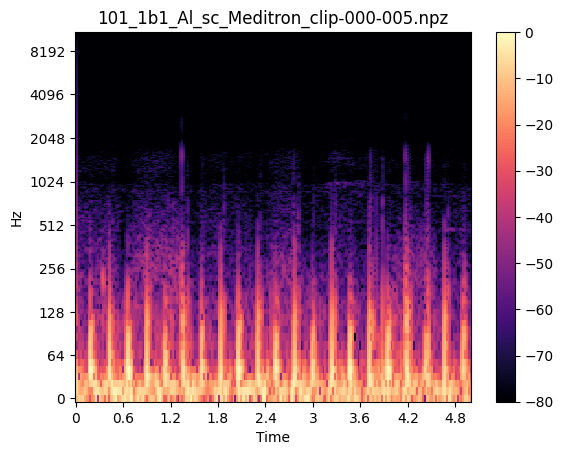

In [4]:
combined_dataset.unit_test(idx=0)

## Other Features

Sample 0:
  File name: 101_1b1_Al_sc_Meditron_clip-000-005.npz
  Label: 7 (URTI)
  Feature shape: (128, 216)
  Feature dtype: float32
  Feature min value: -80.000
  Feature max value: 0.000


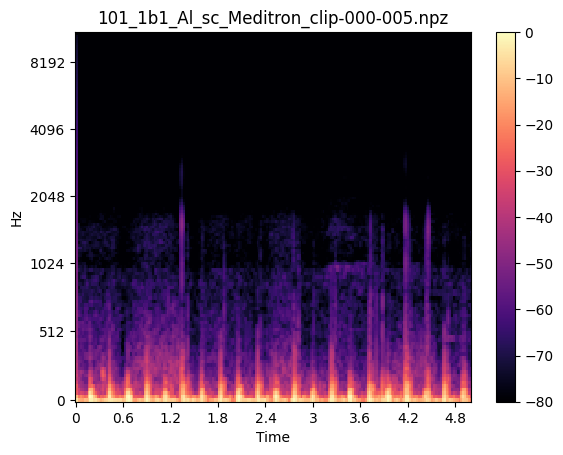

In [5]:
extractor = "MelSpectrogram"
combined = CombinedFeaturesDataset(DATA_FOLDER, "all", feature_extractor=extractor, classes=SELECTED_CLASSES, random_seed=SEED)
combined.unit_test(idx=0)

Sample 0:
  File name: 101_1b1_Al_sc_Meditron_clip-000-005.npz
  Label: 7 (URTI)
  Feature shape: (128, 216)
  Feature dtype: float32
  Feature min value: -480.105
  Feature max value: 193.862


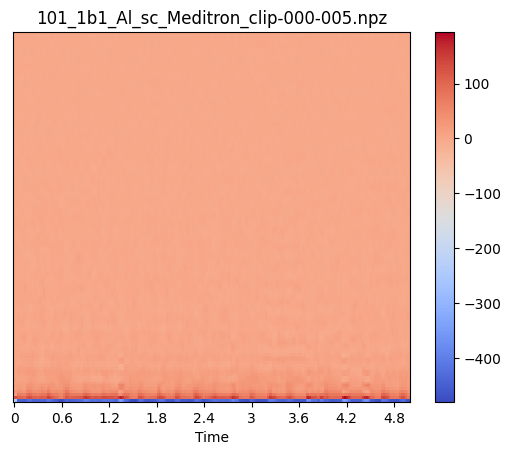

In [6]:
extractor = "MFCC"
combined = CombinedFeaturesDataset(DATA_FOLDER, "all", feature_extractor=extractor, classes=SELECTED_CLASSES, random_seed=SEED)
combined.unit_test(idx=0)

Sample 0:
  File name: 101_1b1_Al_sc_Meditron_clip-000-005.npz
  Label: 7 (URTI)
  Feature shape: (128, 216)
  Feature dtype: float32
  Feature min value: 0.312
  Feature max value: 1.000


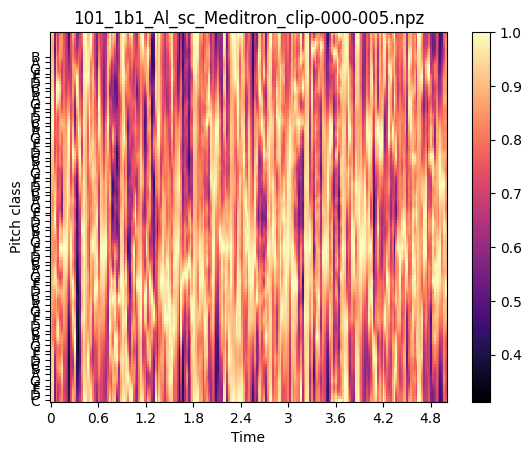

In [7]:
extractor = "Chroma"
combined = CombinedFeaturesDataset(DATA_FOLDER, "all", feature_extractor=extractor, classes=SELECTED_CLASSES, random_seed=SEED)
combined.unit_test(idx=0)

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-480.10492..193.86206].


Sample 0:
  File name: 101_1b1_Al_sc_Meditron_clip-000-005.npz
  Label: 7 (URTI)
  Feature shape: (128, 216, 3)
  Feature dtype: float32
  Feature min value: -480.105
  Feature max value: 193.862


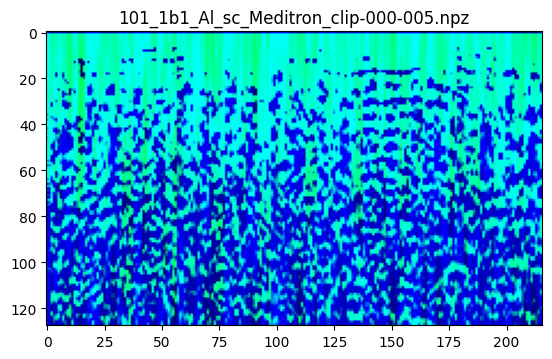

In [8]:
extractor = "Stack_MelSpectrogram_MFCC_Chroma"
combined = CombinedFeaturesDataset(DATA_FOLDER, "all", feature_extractor=extractor, classes=SELECTED_CLASSES, random_seed=SEED)
combined.unit_test(idx=0)